# Genomic Sequence Analysis of *Mycobacterium africanum* Clinical Isolates from Ghana
## Using Biopython and NCBI GenBank Data

### Aims

This analysis addresses three questions:
1. What is the GC content of rpoB and hsp65 gene sequences from Ghanaian *M. africanum* isolates, and is it consistent with known mycobacterial signatures?
2. Are the sequences free of ambiguous bases that could affect analysis quality?
3. How do the three Ghanaian rpoB strains differ from each other at the sequence level, and what do those differences suggest about local genetic diversity?

### Data Source
Four partial gene sequences from *M. africanum* clinical isolates collected from Ghanaian TB patients, sourced from NCBI GenBank (accessions FJ617583–FJ617586). All sequences are from a study on genotypic profiles of *M. africanum* clades in Ghana (Goncalves Vasconcellos et al.).

### Methods Overview

Sequence data were retrieved from NCBI GenBank and analyzed using Python and Biopython. The workflow included sequence verification, GC-content analysis, quality assessment through ambiguous-base detection, and pairwise sequence comparison to identify SNP differences among Ghanaian isolates.

In [1]:
from Bio import SeqIO
print('Biopython imported successfully')

Biopython imported successfully


In [2]:
# Parse the FASTA file and print the basic info for each sequence

for record in SeqIO.parse("ghana_tb_sequences.fasta", "fasta"):
    print(record.id)

FJ617586.1
FJ617585.1
FJ617584.1
FJ617583.1


### 1. Loading and Verifying Sequences
The FASTA file containing four *M. africanum* sequences from Ghana is parsed using Biopython's SeqIO module. Each sequence is verified by printing its ID, length, and the first 50 bases.

In [3]:
## Loop through each sequence in the FASTA file

for record in SeqIO.parse("ghana_tb_sequences.fasta", "fasta"):
    print(F"ID: {record.id}")
    print(F"Length: {len(record.seq)}bp")
    print(F"Sequence: {record.seq[:50]}...") # First 50 bases only
     

ID: FJ617586.1
Length: 360bp
Sequence: TCAAGGAGAAGCGCTACGACCTGGCCCGCGTCGGTCGCTATAAGGTCAAC...
ID: FJ617585.1
Length: 360bp
Sequence: TCAAGGAGAAGCGCTACGACCTGGCCCGCGTCGGTCGCTATAAGGTCAAC...
ID: FJ617584.1
Length: 360bp
Sequence: TCAAGGAGAAGCGCTACGACCTGGCCCGCGTCGGTCGCTATAAGGTCAAC...
ID: FJ617583.1
Length: 441bp
Sequence: ACCAACGATGGTGTGTCCATCGCCAAGGAGATCGAGCTGGAGGATCCGTA...


### 2. GC Content Analysis
GC content is calculated for each sequence using Biopython's 'gc_fraction' function. High GC content (~65%) is a known characteristic of *M. tuberculosis* complex organisms. 

In [4]:
# Calculate GC content for each sequence
from Bio.SeqUtils import gc_fraction

for record in SeqIO.parse("ghana_tb_sequences.fasta", "fasta"):
    gc = gc_fraction(record.seq) * 100
    print(f"{record.id}: GC content = {gc:.2f}%")

FJ617586.1: GC content = 63.06%
FJ617585.1: GC content = 63.33%
FJ617584.1: GC content = 62.78%
FJ617583.1: GC content = 64.17%


In [5]:
# Check sequence length and count ambiguous bases (N) for quality control
for record in SeqIO.parse("ghana_tb_sequences.fasta", "fasta"):
    n_count = record.seq.count("N")
    print(f"{record.id}: Length = {len(record.seq)} bp Ambiguous bases(N) = {n_count}")

FJ617586.1: Length = 360 bp Ambiguous bases(N) = 0
FJ617585.1: Length = 360 bp Ambiguous bases(N) = 0
FJ617584.1: Length = 360 bp Ambiguous bases(N) = 0
FJ617583.1: Length = 441 bp Ambiguous bases(N) = 0


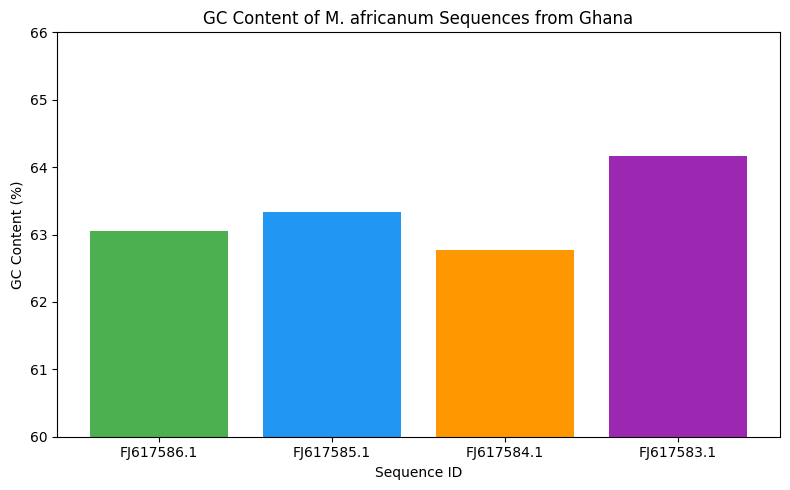

In [6]:
import matplotlib.pyplot as plt

# Collect IDs and GC values for plotting
ids = []
gc_values = []

for record in SeqIO.parse("ghana_tb_sequences.fasta", "fasta"):
    ids.append(record.id)
    gc_values.append(gc_fraction(record.seq) * 100)

# Plot bar chart — y-axis starts at 60 to make differences visible
plt.figure(figsize=(8, 5))
plt.bar(ids, gc_values, color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'])
plt.ylim(60, 66)
plt.xlabel("Sequence ID")
plt.ylabel("GC Content (%)")
plt.title("GC Content of M. africanum Sequences from Ghana")
plt.tight_layout()
plt.savefig("gc_content_plot.png")
plt.show()

### 3. Summary Table
A structured summary of sequence length, GC content, and ambiguous base count for all four sequences.

In [7]:
# Summary table with fixed-width columns for clean alignment
print(f"{'Accession':<15} {'Gene':<8} {'Length (bp)':<14} {'GC Content (%)':<16} {'Ambiguous (N)'}")
  
# Map accession numbers to gene names
genes = {"FJ617586.1": "rpoB", "FJ617585.1": "rpoB", "FJ617584.1": "rpoB", "FJ617583.1": "hsp65"}

for record in SeqIO.parse("ghana_tb_sequences.fasta", "fasta"):
    gc = gc_fraction(record.seq) * 100
    n_count = record.seq.count("N")
    gene = genes[record.id]
    print(f"{record.id:<15} {gene:<8} {len(record.seq):<14} {gc:<16.2f} {n_count}")

Accession       Gene     Length (bp)    GC Content (%)   Ambiguous (N)
FJ617586.1      rpoB     360            63.06            0
FJ617585.1      rpoB     360            63.33            0
FJ617584.1      rpoB     360            62.78            0
FJ617583.1      hsp65    441            64.17            0


### 4. Pairwise Sequence Comparison
The three rpoB sequences are compared directly against each other to identify exact SNP positions and quantify genetic differences between Ghanaian strains.

In [8]:
# Compare three rpoB sequences base by base and print SNP positions for each pair

records = list(SeqIO.parse("ghana_tb_sequences.fasta", "fasta"))

seq1 = records[0]
seq2 = records[1]
seq3 = records[2]

print(f"Comparing rpoB sequences: {seq1.id} vs {seq2.id} vs {seq3.id}")
 

differences_12 = []
differences_13 = []
differences_23 = []

for i in range(len(seq1.seq)):
    if seq1.seq[i] != seq2.seq[i]:
        differences_12.append((i+1, seq1.seq[i], seq2.seq[i]))
    if seq1.seq[i] != seq3.seq[i]:
        differences_13.append((i+1, seq1.seq[i], seq3.seq[i]))
    if seq2.seq[i] != seq3.seq[i]:
        differences_23.append((i+1, seq2.seq[i], seq3.seq[i]))

print(f"\n{seq1.id} vs {seq2.id}: {len(differences_12)} difference(s)")
for pos, b1, b2 in differences_12:
    print(f"  Position {pos}: {b1} → {b2}")

print(f"\n{seq1.id} vs {seq3.id}: {len(differences_13)} difference(s)")
for pos, b1, b3 in differences_13:
    print(f"  Position {pos}: {b1} → {b3}")

print(f"\n{seq2.id} vs {seq3.id}: {len(differences_23)} difference(s)")
for pos, b1, b2 in differences_23:
    print(f"  Position {pos}: {b1} → {b2}")

Comparing rpoB sequences: FJ617586.1 vs FJ617585.1 vs FJ617584.1

FJ617586.1 vs FJ617585.1: 1 difference(s)
  Position 280: T → C

FJ617586.1 vs FJ617584.1: 1 difference(s)
  Position 166: C → T

FJ617585.1 vs FJ617584.1: 2 difference(s)
  Position 166: C → T
  Position 280: C → T


### 5. Visualization
A heatmap showing pairwise SNP differences between the three Ghanaian rpoB strains. Darker cells indicate more differences.

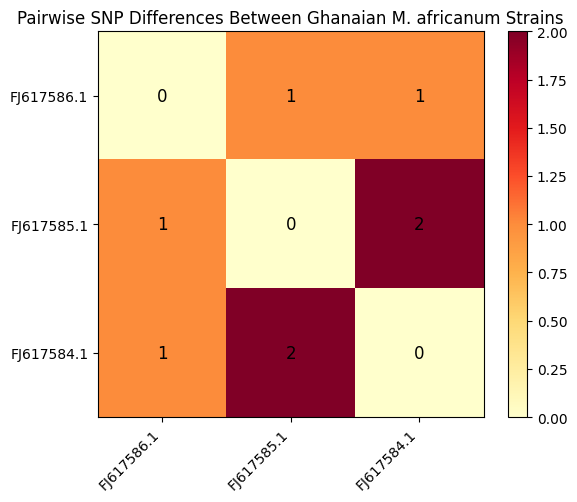

In [9]:
# Heatmap of pairwise SNP differences — darker colour means more differences
import matplotlib.pyplot as plt
import numpy as np

labels = [seq1.id, seq2.id, seq3.id]
matrix = [
    [0, len(differences_12), len(differences_13)],
    [len(differences_12), 0, len(differences_23)],
    [len(differences_13), len(differences_23), 0]
]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix, cmap="YlOrRd")

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

for i in range(3):
    for j in range(3):
        ax.text(j, i, matrix[i][j], ha="center", va="center", color="black", fontsize=12)

plt.colorbar(im)
plt.title("Pairwise SNP Differences Between Ghanaian M. africanum Strains")
plt.tight_layout()
plt.savefig("snp_heatmap.png")
plt.show()

## Conclusions

1. All four sequences have GC content between 62–64%, consistent with the known high-GC signature of the *M. tuberculosis* complex.
2. No ambiguous bases were found in any sequence, confirming data quality.
3. The three rpoB strains differ from each other at two positions — position 166 and position 280. FJ617585 and FJ617584 are the most divergent (2 differences), while FJ617586 is intermediate (1 difference from each).
4. This inter-strain variation suggests at least two distinct rpoB variants of *M. africanum* are circulating in Ghana, indicating local genetic diversity with potential implications for TB drug-resistance surveillance.